# MDR-TS v4.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v4.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**
- Replaced the single XGB regressor with a two-stage modeling strategy
- **Model A**learns the dominant soil-moisture drivers (rainfall, API, seasonality, static context)
- **Model B** learns the residual signal left behind by **Model A** (radar, optical, LST dynamics)
- Final prediction is the sum of both models:

$$\hat{y}_t = \hat{y}_t^{(A)} + \hat{r}_t^{(B)}$$

Why this matters
- Prevents rainfall and seasonality from drowning out weaker satellite signals
- Forces radar and optical features to explain only what physics hasn’t already covered
- Adds structural modeling power without changing the target or inflating feature count

This version focuses on signal separation, not feature bloat or hyperparameter tuning.

For other info see `MDR-TS-v1.0`

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [4]:
# Project paths
VERSION = "v4"
SUBVERSION = "v4.1"
RUN_NAME = "mdr_ts_v4_1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v4/v4.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [5]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_all/train_derived_all.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_all/val_derived_all.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_all/test_derived_all.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/train_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/val_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/test_derived_all.csv
train: dropped columns ['slope', 'elev']

train: shape=(15904, 94)
train: columns=94
val: dropped columns ['slope', 'elev']

val: shape=(3408, 94)
val: columns=94
test: dropped columns ['slope', 'elev']

test: shape=(3408, 94)
test: columns=94


In [6]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 94

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_grad_G_API_kobs7', 'A_pct_G_API', 'V_rollstd_G_API_kobs7']


## 4. Data Sanity Checks

In [7]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'A_d_E_SAR_ratio_kobs1',
    'A_d_F_NDMI_kobs1',
    'A_d_G_API_kobs1',
    'A_d_LST_modis_kobs1',
    'C_smm_E_SAR_ratio_alpha0.85_n5',
    'C_smm_F_NDMI_alpha0.85_n5',
    'C_smm_G_API_alpha0.85_n5',
    'C_smm_LST_modis_alpha0.85_n5',
    'DOY',
    'D_sa_E_SAR_ratio',
    'D_sa_F_NDMI',
    'D_sa_LST_modis',
    'D_z_E_SAR_ratio',
    'D_z_F_NDMI',
    'D_z_LST_modis',
    'E_SAR_diff',
    'E_SAR_ratio',
    'F_MSI',
    'F_NDMI',
    'F_NDVI',
    'G_API',
    'G_DSLR',
    'G_DSLR_isnan',
    'G_rain_sum_30d',
    'G_rain_sum_3d',
    'G_rain_sum_7d',
    'I_ts_spike_s1_vv',
    'LST_modis',
    'V_rollstd_E_SAR_ratio_kobs7',
    'V_rollstd_F_NDMI_kobs7',
    'V_rollstd_G_API_kobs7',
    'V_rollstd_LST_modis_kobs7',
    'aspect',
    'precip_mm',
    's1_vh',
    's1_vv',
    's2_b11',
    's2_b12',
    's2_b4',
    's2_b8'
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 40
  Target:   soil_moisture_5cm


In [8]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[OK] station Touchet_WA_824: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [9]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-08-17 00:00:00
    val   min date: 2021-08-18 00:00:00
  Station Quinault:
    train max date: 2021-09-03 00:00:00
    val   min date: 2021-09-04 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-05-13 00:00:00
    val   min date: 2021-05-14 00:00:00
  Station Spokane:
    train max date: 2021-09-19 00:00:00
    val   min date: 2021-09-20 00:00:00
  Station Touchet_WA_824:
    train max date: 2018-06-07 00:00:00
    val   min date: 2018-06-08 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [10]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     15904
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-19 00:00:00

VAL
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2018-06-08 00:00:00 -- 2023-12-29 00:00:00

TEST
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2019-11-12 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [12]:
def split_features(feature_cols):
    A, B = [], []

    for c in feature_cols:
        if c in {"precip_mm", "DOY", "aspect"}:
            A.append(c)
        elif c.startswith(("G_", "D_")):
            A.append(c)
        elif c in {"LST_modis", "F_NDVI", "F_NDMI", "F_MSI", "E_SAR_ratio", "E_SAR_diff"}:
            B.append(c)
        elif c.startswith(("E_", "F_", "A_", "V_", "C_", "I_")):
            B.append(c)
        else:
            B.append(c)

    return sorted(set(A)), sorted(set(B))

FEATURES_A, FEATURES_B = split_features(FEATURE_COLS)

print("Model A features:", len(FEATURES_A))
print("Model B features:", len(FEATURES_B))
print("A:", FEATURES_A)
print("B:", FEATURES_B)

X_train_A = train_df[FEATURES_A].copy()
X_val_A   = val_df[FEATURES_A].copy()
X_test_A  = test_df[FEATURES_A].copy()

X_train_B = train_df[FEATURES_B].copy()
X_val_B   = val_df[FEATURES_B].copy()
X_test_B  = test_df[FEATURES_B].copy()

y_train = train_df[TARGET_COL].copy()
y_val   = val_df[TARGET_COL].copy()
y_test  = test_df[TARGET_COL].copy()

print("Shapes:")
print("  X_train_A:", X_train_A.shape, " | X_train_B:", X_train_B.shape)
print("  X_val_A:  ", X_val_A.shape,   " | X_val_B:  ", X_val_B.shape)
print("  X_test_A: ", X_test_A.shape,  " | X_test_B: ", X_test_B.shape)
print("  y_train:  ", y_train.shape)

Model A features: 15
Model B features: 25
A: ['DOY', 'D_sa_E_SAR_ratio', 'D_sa_F_NDMI', 'D_sa_LST_modis', 'D_z_E_SAR_ratio', 'D_z_F_NDMI', 'D_z_LST_modis', 'G_API', 'G_DSLR', 'G_DSLR_isnan', 'G_rain_sum_30d', 'G_rain_sum_3d', 'G_rain_sum_7d', 'aspect', 'precip_mm']
B: ['A_d_E_SAR_ratio_kobs1', 'A_d_F_NDMI_kobs1', 'A_d_G_API_kobs1', 'A_d_LST_modis_kobs1', 'C_smm_E_SAR_ratio_alpha0.85_n5', 'C_smm_F_NDMI_alpha0.85_n5', 'C_smm_G_API_alpha0.85_n5', 'C_smm_LST_modis_alpha0.85_n5', 'E_SAR_diff', 'E_SAR_ratio', 'F_MSI', 'F_NDMI', 'F_NDVI', 'I_ts_spike_s1_vv', 'LST_modis', 'V_rollstd_E_SAR_ratio_kobs7', 'V_rollstd_F_NDMI_kobs7', 'V_rollstd_G_API_kobs7', 'V_rollstd_LST_modis_kobs7', 's1_vh', 's1_vv', 's2_b11', 's2_b12', 's2_b4', 's2_b8']
Shapes:
  X_train_A: (15904, 15)  | X_train_B: (15904, 25)
  X_val_A:   (3408, 15)  | X_val_B:   (3408, 25)
  X_test_A:  (3408, 15)  | X_test_B:  (3408, 25)
  y_train:   (15904,)


### 6.2 Baseline Model Definition

In [13]:
MODEL_CONFIG = {
    "n_estimators": 500,          # upper bound, early stopping will cap it
    "max_depth": 5, # can try 6 with stronger regularization
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
}

MODEL_CONFIG_A = dict(MODEL_CONFIG)

MODEL_CONFIG_B = dict(MODEL_CONFIG)
MODEL_CONFIG_B["max_depth"] = 3

print("MODEL_CONFIG:")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

MODEL_CONFIG:
  n_estimators: 500
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.0
  reg_lambda: 1.0
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1


## 7. Training Loop

### 7.1 Fit Model

In [14]:
model_A = XGBRegressor(**MODEL_CONFIG_A)
model_A.fit(
    X_train_A, y_train,
    eval_set=[(X_train_A, y_train), (X_val_A, y_val)],
    verbose=50,
)

yhatA_train = model_A.predict(X_train_A)
yhatA_val   = model_A.predict(X_val_A)
yhatA_test  = model_A.predict(X_test_A)

r_train = y_train.values - yhatA_train
r_val   = y_val.values - yhatA_val
r_test  = y_test.values - yhatA_test

model_B = XGBRegressor(**MODEL_CONFIG_B)
model_B.fit(
    X_train_B, r_train,
    eval_set=[(X_train_B, r_train), (X_val_B, r_val)],
    verbose=50,
)

rhat_train = model_B.predict(X_train_B)
rhat_val   = model_B.predict(X_val_B)
rhat_test  = model_B.predict(X_test_B)

yhat_train = yhatA_train + rhat_train
yhat_val   = yhatA_val   + rhat_val
yhat_test  = yhatA_test  + rhat_test

print("Training complete (two-stage)")
print("  yhat_train:", yhat_train.shape)
print("  yhat_val:  ", yhat_val.shape)
print("  yhat_test: ", yhat_test.shape)

[0]	validation_0-rmse:0.09807	validation_1-rmse:0.10381
[50]	validation_0-rmse:0.03858	validation_1-rmse:0.04872
[100]	validation_0-rmse:0.03282	validation_1-rmse:0.04686
[150]	validation_0-rmse:0.03027	validation_1-rmse:0.04695
[200]	validation_0-rmse:0.02815	validation_1-rmse:0.04686
[250]	validation_0-rmse:0.02651	validation_1-rmse:0.04711
[300]	validation_0-rmse:0.02498	validation_1-rmse:0.04709
[350]	validation_0-rmse:0.02369	validation_1-rmse:0.04710
[400]	validation_0-rmse:0.02260	validation_1-rmse:0.04718
[450]	validation_0-rmse:0.02159	validation_1-rmse:0.04717
[499]	validation_0-rmse:0.02070	validation_1-rmse:0.04728
[0]	validation_0-rmse:0.02067	validation_1-rmse:0.04730
[50]	validation_0-rmse:0.02011	validation_1-rmse:0.04766
[100]	validation_0-rmse:0.01978	validation_1-rmse:0.04778
[150]	validation_0-rmse:0.01949	validation_1-rmse:0.04790
[200]	validation_0-rmse:0.01925	validation_1-rmse:0.04807
[250]	validation_0-rmse:0.01905	validation_1-rmse:0.04828
[300]	validation_0-r

### 7.2 Metrics

In [15]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

results = pd.DataFrame([
    metrics_block("train", y_train, yhat_train),
    metrics_block("val",   y_val,   yhat_val),
    metrics_block("test",  y_test,  yhat_test),
])

results

,split,MAE,RMSE,R2
0,train,0.013066,0.018159,0.968199
1,val,0.038249,0.048523,0.795995
2,test,0.046820,0.060158,0.581395


### 7.3 Diagnostics

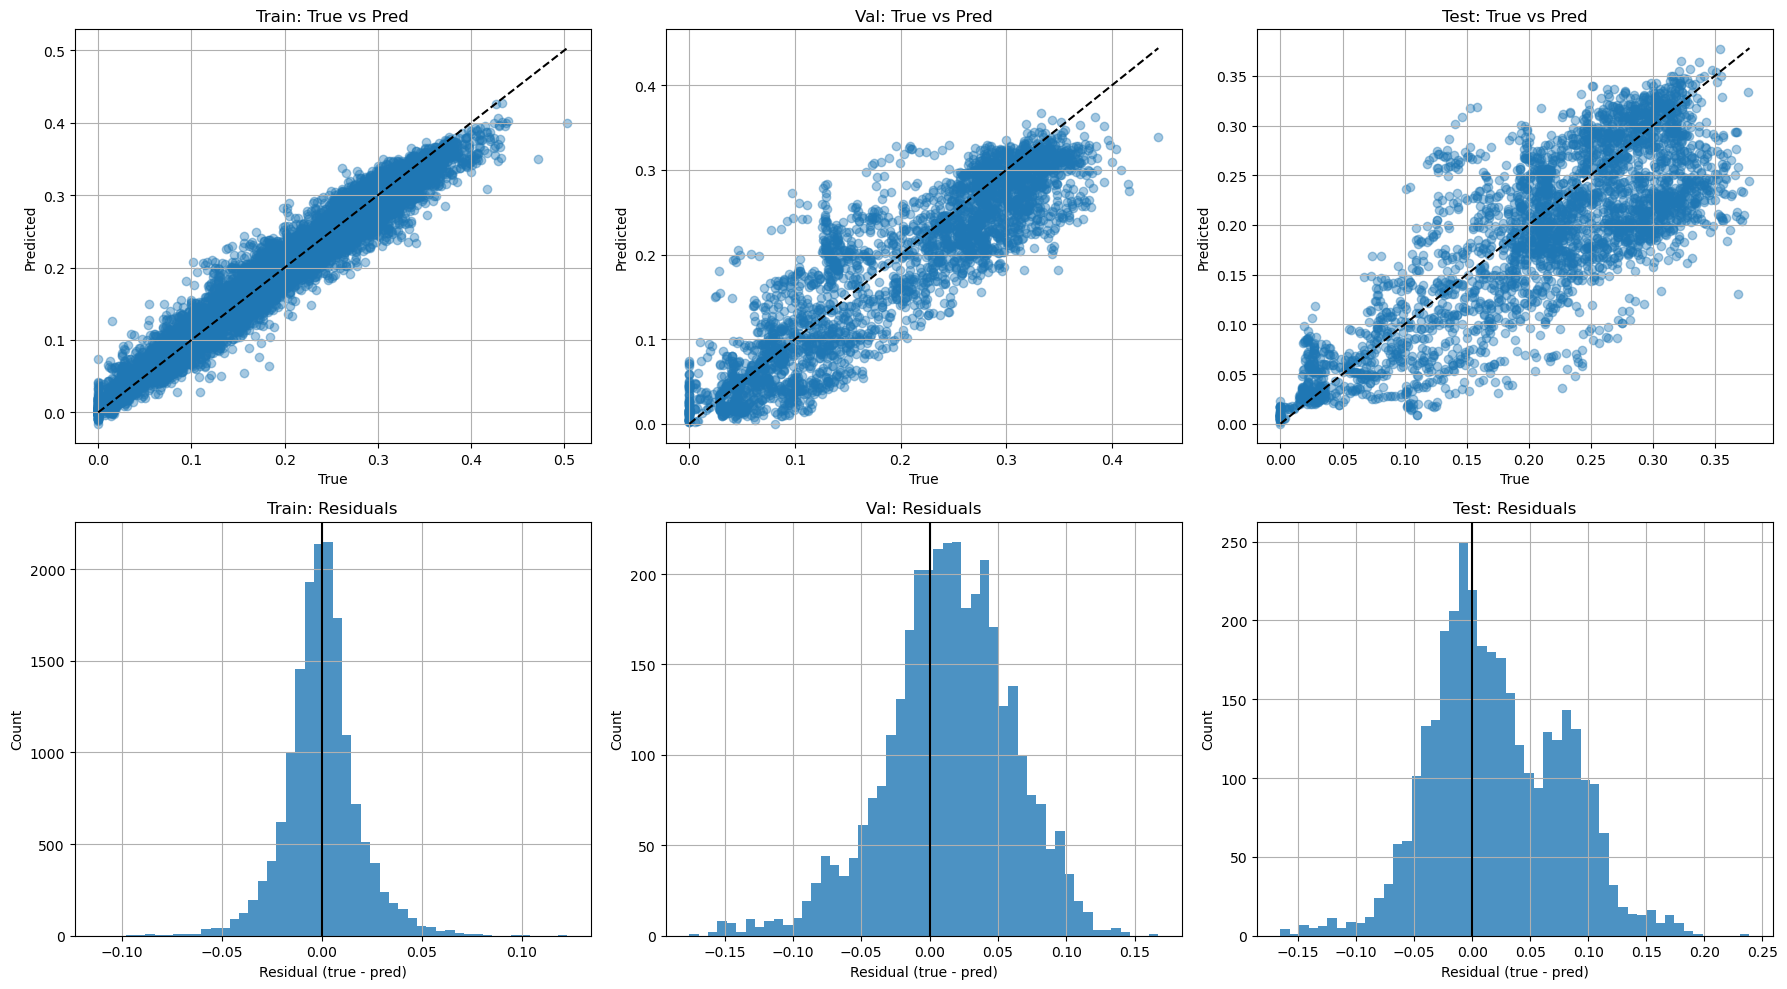

In [16]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test,  "Test: Residuals")

plt.tight_layout()
plt.show()

### 7.4 Feature Importance

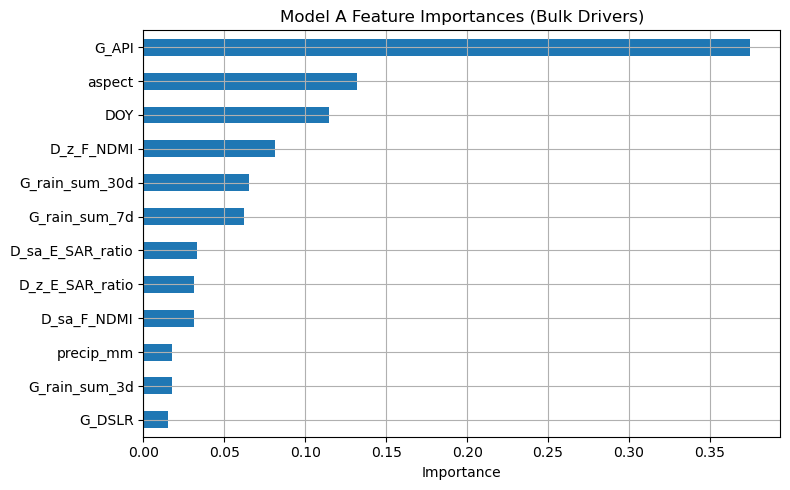

In [17]:
importances_A = (
    pd.Series(model_A.feature_importances_, index=FEATURES_A)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
importances_A.head(12).sort_values().plot(kind="barh")
plt.title("Model A Feature Importances (Bulk Drivers)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

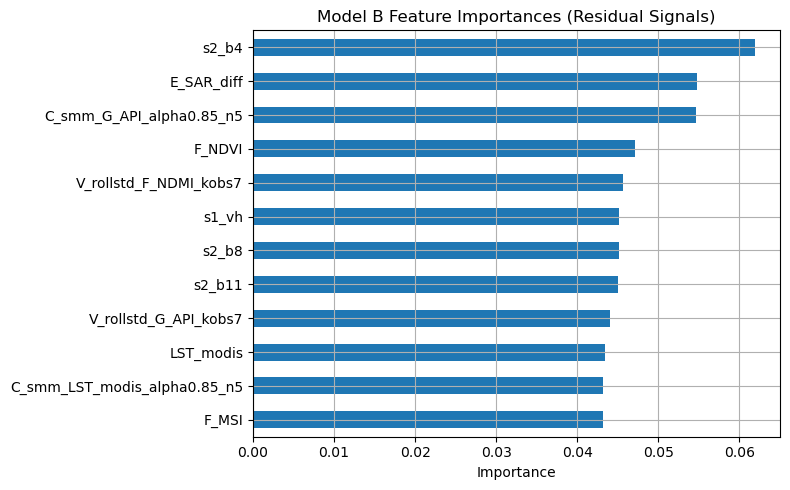

In [18]:
importances_B = (
    pd.Series(model_B.feature_importances_, index=FEATURES_B)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
importances_B.head(12).sort_values().plot(kind="barh")
plt.title("Model B Feature Importances (Residual Signals)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [19]:
importances_A.head(10)

G_API               0.374587
aspect              0.132237
DOY                 0.114629
D_z_F_NDMI          0.081338
G_rain_sum_30d      0.065394
G_rain_sum_7d       0.061847
D_sa_E_SAR_ratio    0.032977
D_z_E_SAR_ratio     0.031417
D_sa_F_NDMI         0.031129
precip_mm           0.017803
dtype: float32

In [20]:
importances_B.head(10)

s2_b4                       0.061907
E_SAR_diff                  0.054743
C_smm_G_API_alpha0.85_n5    0.054701
F_NDVI                      0.047072
V_rollstd_F_NDMI_kobs7      0.045601
s1_vh                       0.045189
s2_b8                       0.045134
s2_b11                      0.045012
V_rollstd_G_API_kobs7       0.044044
LST_modis                   0.043417
dtype: float32

### 7.5 Model A vs Final Performance

In [21]:
results_A = pd.DataFrame([
    metrics_block("train_A", y_train, yhatA_train),
    metrics_block("val_A",   y_val,   yhatA_val),
    metrics_block("test_A",  y_test,  yhatA_test),
])

pd.concat([results_A, results], ignore_index=True)

,split,MAE,RMSE,R2
0,train_A,0.015045,0.020700,0.958679
1,val_A,0.037309,0.047280,0.806316
2,test_A,0.045638,0.058922,0.598423
3,train,0.013066,0.018159,0.968199
4,val,0.038249,0.048523,0.795995
5,test,0.046820,0.060158,0.581395


## 8. Evaluation

### 8.1 Test Metrics

In [22]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test),
    "RMSE": rmse(y_test, yhat_test),
    "R2":   r2_score(y_test, yhat_test),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.04682,0.060158,0.581395,3408


### 8.2 Test Prediction Scatter

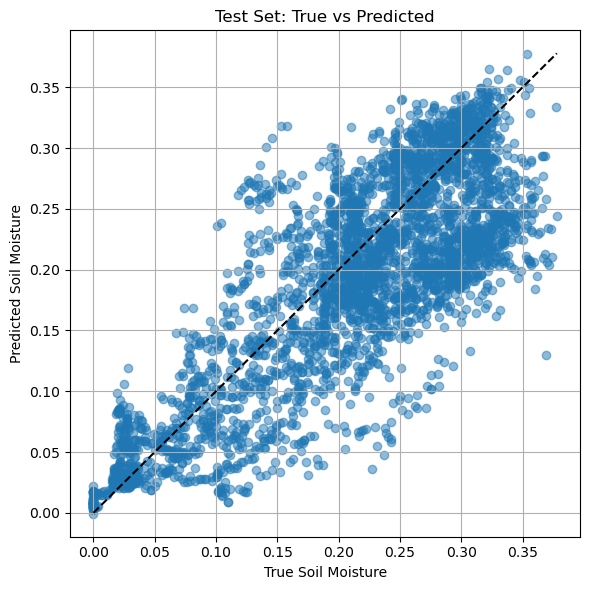

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [24]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val.min()): .6f} to {float(yhat_val.max()): .6f}
TEST range : {float(yhat_test.min()): .6f} to {float(yhat_test.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean :  0.013635
TEST residual mean :  0.021139

Prediction ranges
-----------------
VAL  range : -0.000678 to  0.367178
TEST range : -0.000722 to  0.377338



## 9. Metrics & Visalization

### 9.1 Generalization Gap

In [25]:
results_idx = results.set_index("split")

gap = {
    "train -> val (MAE)": float(results_idx.loc["val", "MAE"] - results_idx.loc["train", "MAE"]),
    "val -> test (MAE)":  float(results_idx.loc["test", "MAE"] - results_idx.loc["val", "MAE"]),
}
pd.DataFrame.from_dict(gap, orient="index", columns=["delta_MAE"])

,delta_MAE
train -> val (MAE),0.025182
val -> test (MAE),0.008571


## 10. Save Artifacts

In [26]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v4/v4.1/mdr_ts_v4_1_20260108_152719


In [27]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

NameError: name 'model' is not defined

In [ ]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234/run_metadata.json


In [ ]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234/metrics.csv


In [ ]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v3/v3.1/mdr_ts_v3_1_20260108_151234/feature_importance.csv


In [ ]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

## 11. Notes & Experiments

Train models with one family of features removed at a time to identify which features harm or help

- Run v4.1 (one more try, minimal changes)
  - Make Model B weaker: max_depth=3, fewer trees (e.g. n_estimators=200), slightly stronger regularization (reg_lambda up)
  - Keep Model A the same as baseline
- Tighten Model B feature set
  - Remove anything “bulk”: G_*, DOY, seasonal D_*, and memory terms like C_smm_G_API*
  - Use mostly: E_* radar, F_* optical, LST_modis + maybe a couple dynamics/volatility terms tied to those
- Add one safety mechanism for residuals
  - Clip residual corrections: rhat = np.clip(rhat, -c, c) (try c=0.05 or based on residual std)
  - Or shrink corrections: yhat = yhatA + 0.5 * rhat (simple scalar gate)
- Evaluate properly
  - Compare Model A only vs A+B on val/test
  - Track: MAE, R², bias, plus residual mean and prediction range
- Decision rule
  - If v4.1 doesn’t beat v3.4 on test MAE or R², stop iterating v4 and document the finding
  - If it improves, then proceed to targeted ablations inside Model B (radar vs optical vs LST)

---

_Jakob Balkovec_